## Imports

In [3]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

## Data

In [4]:
x_train = 2 * torch.rand(200, 2) - 1
x_train

tensor([[ 0.8810, -0.2337],
        [-0.4286, -0.6122],
        [ 0.1873, -0.0280],
        [ 0.5062, -0.3823],
        [ 0.5312, -0.0464],
        [ 0.4607,  0.6184],
        [ 0.2843,  0.0456],
        [-0.0352, -0.0703],
        [-0.0548, -0.6324],
        [-0.9929, -0.1674],
        [-0.0583, -0.5776],
        [ 0.6805,  0.7678],
        [-0.0862,  0.9132],
        [-0.9000, -0.5245],
        [ 0.5812,  0.4701],
        [-0.4772, -0.8442],
        [-0.1450, -0.7204],
        [ 0.0712,  0.2252],
        [ 0.8351, -0.2203],
        [ 0.5450,  0.2554],
        [ 0.1358, -0.4620],
        [ 0.3981,  0.1916],
        [-0.3055,  0.9853],
        [-0.1194, -0.8152],
        [-0.8153,  0.6329],
        [ 0.9442, -0.8080],
        [ 0.5350, -0.5986],
        [ 0.3677,  0.2876],
        [-0.9478, -0.6644],
        [-0.4060,  0.8061],
        [ 0.1707, -0.5978],
        [-0.7169,  0.8134],
        [-0.2745,  0.5106],
        [ 0.1158,  0.4604],
        [-0.4852,  0.7411],
        [ 0.7565,  0

In [5]:
y_train = torch.rand(200)
y_train

tensor([0.1635, 0.7921, 0.2461, 0.8623, 0.6440, 0.5722, 0.1463, 0.8238, 0.7924,
        0.0449, 0.9323, 0.1748, 0.2112, 0.5107, 0.9368, 0.3925, 0.0591, 0.9599,
        0.2647, 0.5209, 0.6507, 0.9514, 0.9013, 0.9025, 0.8063, 0.0535, 0.6739,
        0.8320, 0.9535, 0.6437, 0.1094, 0.1131, 0.5005, 0.3375, 0.9142, 0.5282,
        0.9852, 0.8975, 0.4834, 0.7252, 0.2483, 0.1505, 0.8379, 0.4613, 0.8925,
        0.4372, 0.0656, 0.0213, 0.5948, 0.8254, 0.9198, 0.5304, 0.7917, 0.0033,
        0.0304, 0.6572, 0.5199, 0.8134, 0.4384, 0.0404, 0.5278, 0.1310, 0.6190,
        0.7527, 0.1985, 0.8864, 0.9262, 0.0096, 0.8756, 0.1918, 0.0843, 0.1590,
        0.0606, 0.5069, 0.6964, 0.9299, 0.4888, 0.5144, 0.2984, 0.9233, 0.6941,
        0.5089, 0.4461, 0.7747, 0.3319, 0.3115, 0.2391, 0.9841, 0.4329, 0.9120,
        0.2597, 0.5729, 0.6483, 0.8036, 0.2622, 0.5653, 0.7391, 0.5864, 0.8489,
        0.0428, 0.2732, 0.4233, 0.7118, 0.2925, 0.1394, 0.1441, 0.1945, 0.3248,
        0.5048, 0.1364, 0.6937, 0.6924, 

## Model

In [6]:
mf_distribution = [3, 2]

In [7]:
model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
)

In [8]:
prems = [
    torch.tensor([
        [ 0.8888,  1.4778, -0.9828],
        [ 0.6794,  1.9851,  1.3402],
        [ 0.3820,  1.2675,  0.1291]]), 
    torch.tensor([
        [ 0.2936,  1.4291, -0.4110],
        [ 0.7602,  1.9827,  0.5622]])
    ]

In [9]:
model.set_premises(prems)

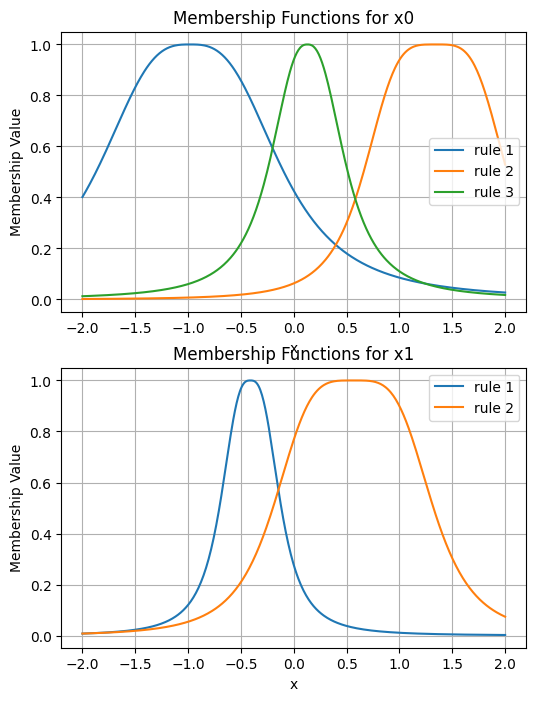

In [10]:
model.plot_premises(group_by_dim=True)

In [11]:
model.get_premises_structure()

x0                      x1                
             a       b       c       a       b       c
rule 1  0.8888  1.4778 -0.9828  0.2936  1.4291 -0.4110
rule 2  0.6794  1.9851  1.3402  0.7602  1.9827  0.5622
rule 3  0.3820  1.2675  0.1291     NaN     NaN     NaN

In [12]:
model.get_premises()

[tensor([[ 0.8888,  1.4778, -0.9828],
         [ 0.6794,  1.9851,  1.3402],
         [ 0.3820,  1.2675,  0.1291]]),
 tensor([[ 0.2936,  1.4291, -0.4110],
         [ 0.7602,  1.9827,  0.5622]])]

## Binary output

In [13]:
x_train = 2 * torch.rand(200, 2) - 1

In [14]:
x_train[:10]

tensor([[-0.8297,  0.3517],
        [-0.3328,  0.4182],
        [ 0.8718, -0.6623],
        [-0.7597,  0.5565],
        [-0.5618,  0.3722],
        [-0.3816,  0.0228],
        [-0.2734, -0.3524],
        [-0.5802,  0.2184],
        [-0.7991,  0.2594],
        [-0.3098, -0.2521]])

In [15]:
mf_distribution

[3, 2]

In [16]:
bin_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    output_type='sigmoid', # Tipo de salida: capa sigmoide
)

In [17]:
bin_model.get_premises()

[tensor([[ 1.0866,  2.3774, -0.9758],
         [ 0.7933,  2.2520, -0.0647],
         [ 0.3249,  2.5078,  0.7714]]),
 tensor([[ 0.6028,  2.8997, -0.8662],
         [ 0.8272,  2.9100, -0.7870]])]

In [18]:
bin_model.get_consequents()

tensor([[[-0.9841, -0.6042, -0.4791],
         [ 0.7171, -0.3426, -0.1074],
         [ 0.7986,  0.4885, -0.2929],
         [-0.2913,  0.9321, -0.7494],
         [-0.2307, -0.2923,  0.4870],
         [ 0.1146, -0.4662, -0.0806]]])

In [19]:
bin_model(x_train[:10])

tensor([0.3652, 0.4079, 0.5265, 0.3796, 0.3924, 0.3817, 0.3763, 0.3835, 0.3675,
        0.3762], grad_fn=<SigmoidBackward0>)

In [20]:
bin_model.predict(x_train[:10])

tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

## Multiclass output

In [21]:
x_train = 2 * torch.rand(200, 2) - 1

In [22]:
mul_class_model = nft.ANFIS(
    mf_distribution=mf_distribution, # Distribución de las funciones de membresía a lo largo de los features
    outputs=3, # 3 clases
    output_type='softmax', # Tipo de salida: capa softmax
)

In [23]:
mul_class_model(x_train[:10])

tensor([[-1.1929, -1.2687, -0.5731],
        [-0.8468, -0.1592,  0.8245],
        [-0.4953, -0.1502, -0.2095],
        [-0.8597, -0.3326, -0.0374],
        [-1.1320, -0.3112,  1.0452],
        [-0.9039, -0.0717,  0.1016],
        [-0.8853, -0.3206,  0.3600],
        [-1.2106, -1.0858, -0.3641],
        [-0.9435, -0.0918,  0.0986],
        [-0.5169,  0.0391, -0.1969]], grad_fn=<SqueezeBackward1>)

In [24]:
mul_class_model(x_train[:10], return_probs=True)

tensor([[0.2641, 0.2449, 0.4910],
        [0.1204, 0.2394, 0.6402],
        [0.2672, 0.3773, 0.3556],
        [0.2012, 0.3409, 0.4579],
        [0.0827, 0.1879, 0.7294],
        [0.1658, 0.3810, 0.4532],
        [0.1604, 0.2822, 0.5574],
        [0.2240, 0.2538, 0.5222],
        [0.1618, 0.3793, 0.4589],
        [0.2427, 0.4231, 0.3342]], grad_fn=<SoftmaxBackward0>)

In [25]:
mul_class_model.predict(x_train[:10])

tensor([2, 2, 1, 2, 2, 2, 2, 2, 2, 1])